<a href="https://colab.research.google.com/github/hmd264/data-science-2026/blob/main/Pertemuan_11_Ahmad_Rilmansyah_240401010309.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM DATA SCIENCE
Pertemuan 9 - Unsupervised Learning:
Clustering (K-Means & Hierarchical)

Nama : Ahmad Rilmansyah

NIM : 240401010309

Prodi : PJJ Informatika

Semester : 4

Dosen : Syahid Abdullah, S.Si., M.Kom.

Tanggal : Juli 2026

## **Generate Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agar hasil selalu sama
np.random.seed(42)

# Membuat 3 kelompok pelanggan
grp1 = np.random.normal([30,20],[6,8],(100,2))
grp2 = np.random.normal([70,55],[8,10],(100,2))
grp3 = np.random.normal([110,85],[10,8],(100,2))

data = np.vstack([grp1,grp2,grp3])

df = pd.DataFrame(data,
                  columns=["pendapatan_tahunan",
                           "skor_belanja"])

df["usia"] = np.random.randint(18,65,len(df))
df["gender"] = np.random.choice(["L","P"],len(df))

print(df.shape)

df.head()

(300, 4)


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


Penjelasan

300 pelanggan
4 atribut

## **Exploratory Data Analysis (EDA)**

In [2]:
df.describe().round(2)

,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00


## **Melihat Sebaran Data**

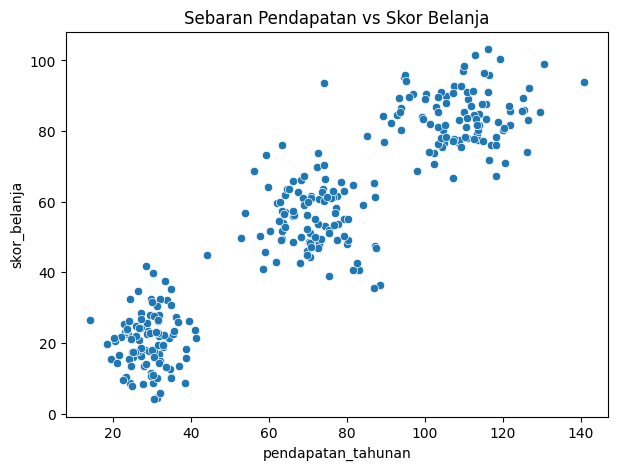

In [3]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja"
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

## **Preprocessing**

In [4]:
from sklearn.preprocessing import StandardScaler

X = df[[
    "pendapatan_tahunan",
    "skor_belanja"
]].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Mean :",X_scaled.mean(axis=0).round(3))
print("Std  :",X_scaled.std(axis=0).round(3))

Mean : [-0.  0.]
Std  : [1. 1.]


## **Metode Elbow**

In [5]:
from sklearn.cluster import KMeans

wcss=[]

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++"
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

## **Grafik Elbow**

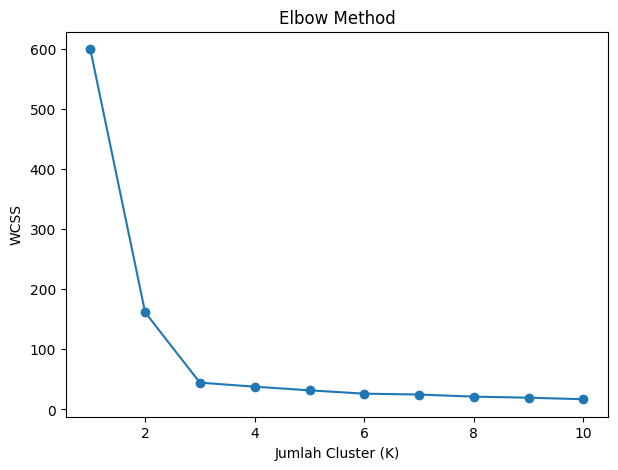

In [6]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

## **Interpretasi**

Berdasarkan grafik Elbow, penurunan WCSS mulai melandai pada K = 3, sehingga jumlah cluster optimal adalah 3. Hasil ini sesuai dengan dataset sintetis yang memang dibangun dari tiga kelompok pelanggan.

## **Melatih Model K-Means**

In [7]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++"
)

model.fit(X_scaled)

df["cluster"] = model.labels_

print("WCSS :",model.inertia_)

print("Silhouette Score :",
      silhouette_score(
          X_scaled,
          model.labels_
      ))

WCSS : 44.5564179805733
Silhouette Score : 0.6953274658286891


## **Rata-rata Tiap Cluster**

In [8]:
df.groupby("cluster")[
[
"pendapatan_tahunan",
"skor_belanja"
]
].mean().round(2)

,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


## **Visualisasi Hasil Clustering**

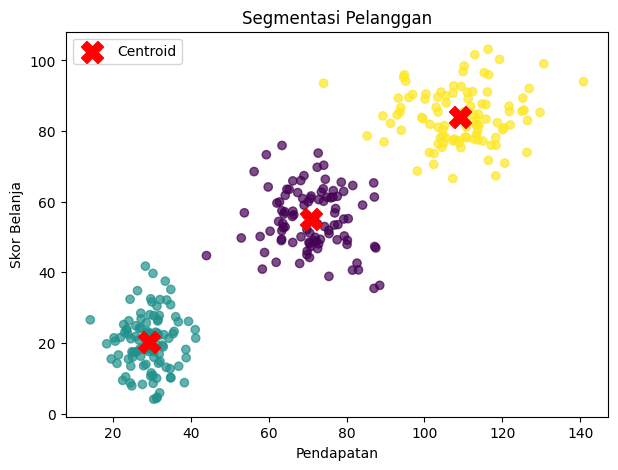

In [9]:
centroids = scaler.inverse_transform(
    model.cluster_centers_
)

plt.figure(figsize=(7,5))

plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c="red",
    marker="X",
    s=250,
    label="Centroid"
)

plt.xlabel("Pendapatan")
plt.ylabel("Skor Belanja")

plt.title("Segmentasi Pelanggan")

plt.legend()

plt.show()

## **Interpretasi Cluster**

Interpretasi

Cluster 0

Pendapatan rendah dan skor belanja rendah.

→ Pelanggan hemat.

Cluster 1

Pendapatan sedang dan skor belanja sedang.

→ Pelanggan menengah.

Cluster 2

Pendapatan tinggi dan skor belanja tinggi.

→ Pelanggan premium atau boros.

## **Hierarchical Clustering**

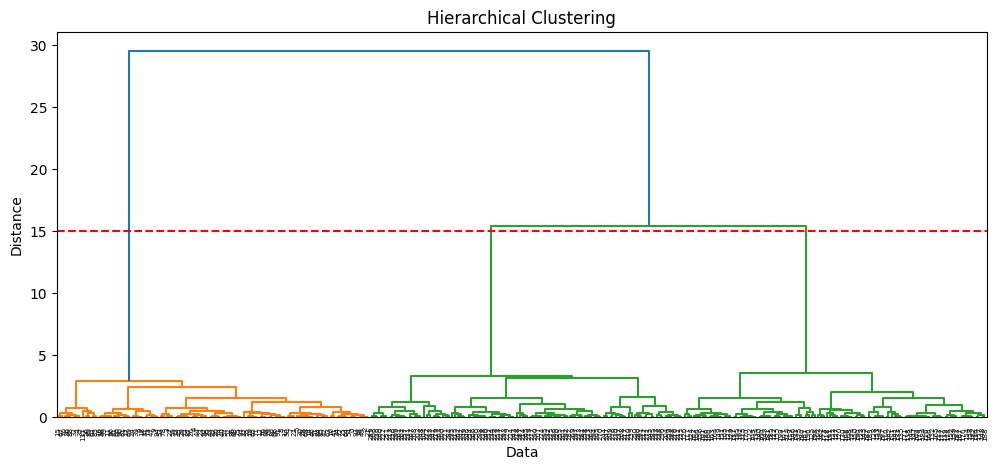

In [10]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage

Z = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12,5))

dendrogram(Z)

plt.axhline(
    y=15,
    color="red",
    linestyle="--"
)

plt.title("Hierarchical Clustering")

plt.xlabel("Data")

plt.ylabel("Distance")

plt.show()

## **Interpretasi Dendrogram**

Interpretasi

Berdasarkan dendrogram, jika garis horizontal dipotong pada jarak tertentu, diperoleh sekitar 3 cluster. Hasil ini konsisten dengan Metode Elbow pada algoritma K-Means, sehingga jumlah cluster yang dipilih dapat dianggap optimal.

## **Kesimpulan**

Pada praktikum ini dilakukan segmentasi pelanggan menggunakan algoritma K-Means dan Hierarchical Clustering. Setelah dilakukan preprocessing dan analisis menggunakan Metode Elbow, diperoleh jumlah cluster optimal sebanyak 3 cluster. Nilai Silhouette Score menunjukkan kualitas pengelompokan yang baik. Visualisasi hasil clustering memperlihatkan tiga kelompok pelanggan dengan karakteristik berbeda, yaitu pelanggan hemat, pelanggan menengah, dan pelanggan premium. Hasil Hierarchical Clustering melalui dendrogram juga mendukung bahwa pembagian menjadi tiga cluster merupakan pilihan yang sesuai.